# **Data Collection**

In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

In [8]:
import pandas as pd
print(pd.__version__)

2.3.1


In [ ]:
file_path = "yield_df.csv"

# Load the latest version
data = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "patelris/crop-yield-prediction-dataset",
  file_path
)

data.head()

## **Feature Extraction**

In [ ]:
data = data.loc[:, 'Item':].drop('Year', axis=1)
data.head()

,Item,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Maize,36613,1485.0,121.0,16.37
1,Potatoes,66667,1485.0,121.0,16.37
2,"Rice, paddy",23333,1485.0,121.0,16.37
3,Sorghum,12500,1485.0,121.0,16.37
4,Soybeans,7000,1485.0,121.0,16.37


In [ ]:
X = data.drop('hg/ha_yield', axis=1)
Y = data['hg/ha_yield']
X.head()

,Item,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Maize,1485.0,121.0,16.37
1,Potatoes,1485.0,121.0,16.37
2,"Rice, paddy",1485.0,121.0,16.37
3,Sorghum,1485.0,121.0,16.37
4,Soybeans,1485.0,121.0,16.37


In [ ]:
Y.head()

,hg/ha_yield
0,36613
1,66667
2,23333
3,12500
4,7000


## **Data Analysis**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

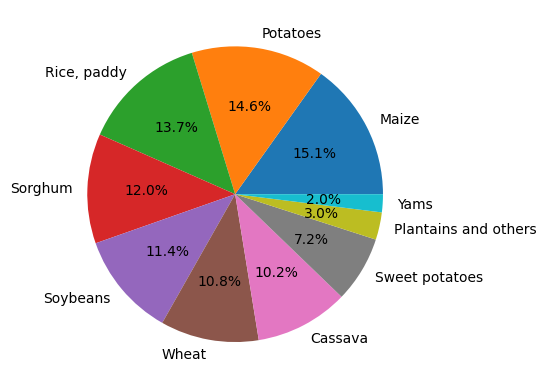

In [ ]:
labels_crop  = X['Item'].unique()
plt.pie(X['Item'].value_counts(), labels=labels_crop, autopct='%1.1f%%')
plt

- May perform bad for  Yams, Plantains and others

In [ ]:
data.describe()

,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,28242.000000,28242.00000,28242.000000,28242.000000
mean,77053.332094,1149.05598,37076.909344,20.542627
std,84956.612897,709.81215,59958.784665,6.312051
min,50.000000,51.00000,0.040000,1.300000
25%,19919.250000,593.00000,1702.000000,16.702500
50%,38295.000000,1083.00000,17529.440000,21.510000
75%,104676.750000,1668.00000,48687.880000,26.000000
max,501412.000000,3240.00000,367778.000000,30.650000


from matplotlib import pyplot as plt
_df_0['hg/ha_yield'].plot(kind='hist', bins=20, title='hg/ha_yield')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['average_rain_fall_mm_per_year'].plot(kind='hist', bins=20, title='average_rain_fall_mm_per_year')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['pesticides_tonnes'].plot(kind='hist', bins=20, title='pesticides_tonnes')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['avg_temp'].plot(kind='hist', bins=20, title='avg_temp')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
_df_6.plot(kind='scatter', x='pesticides_tonnes', y='avg_temp', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_7['hg/ha_yield'].plot(kind='line', figsize=(8, 4), title='hg/ha_yield')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_8['average_rain_fall_mm_per_year'].plot(kind='line', figsize=(8, 4), title='average_rain_fall_mm_per_year')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_9['pesticides_tonnes'].plot(kind='line', figsize=(8, 4), title='pesticides_tonnes')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_10['avg_temp'].plot(kind='line', figsize=(8, 4), title='avg_temp')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:
labels_crop

array(['Maize', 'Potatoes', 'Rice, paddy', 'Sorghum', 'Soybeans', 'Wheat',
       'Cassava', 'Sweet potatoes', 'Plantains and others', 'Yams'],
      dtype=object)

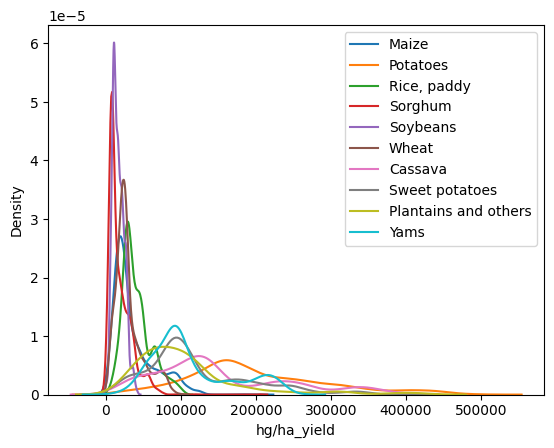

In [ ]:
# Comparative analysis on Y for crop types
for crop in labels_crop:
  sns.kdeplot(data[data['Item'] == crop]['hg/ha_yield'], label = crop)
plt.legend()

- Potatao, Yams, Plantanis, Cassava, Sweet Potatoes give always high (100000 < ) range

In [ ]:
# Recording the max yeild of
crop_highest_yeild = [data[data['Item'] == crop]['hg/ha_yield'].max() for crop in labels_crop]

# Creating the df
crop_highest_yeild_df = pd.DataFrame({'Crop': labels_crop, 'Highest Yeild': crop_highest_yeild})

# Sorting the df based on Highest Yeild
crop_highest_yeild_df = crop_highest_yeild_df.sort_values(by='Highest Yeild', ascending=False)
crop_highest_yeild_df.reset_index(drop=True, inplace=True)

crop_highest_yeild_df

,Crop,Highest Yeild
0,Potatoes,501412
1,Plantains and others,418505
2,Sweet potatoes,400000
3,Cassava,385818
4,Yams,250000
5,Maize,207556
6,Sorghum,206000
7,"Rice, paddy",103895
8,Wheat,99387
9,Soybeans,41609


In [ ]:
sorted_crop_names = crop_highest_yeild_df['Crop'].values
sorted_crop_names

array(['Potatoes', 'Plantains and others', 'Sweet potatoes', 'Cassava',
       'Yams', 'Maize', 'Sorghum', 'Rice, paddy', 'Wheat', 'Soybeans'],
      dtype=object)

- Index of the particular crop type in the df needs to be its corresponding numerical value

<Axes: xlabel='average_rain_fall_mm_per_year', ylabel='hg/ha_yield'>

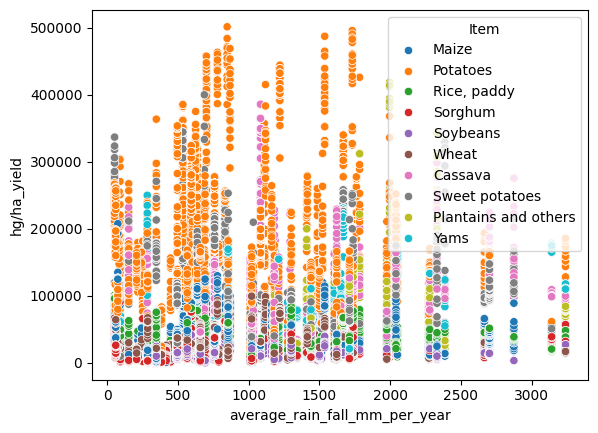

In [ ]:
# Linearity find between Y and X[average_rain_fall_mm_per_year]
sns.scatterplot(x=X['average_rain_fall_mm_per_year'], y=Y, hue=X['Item'])


<Axes: xlabel='pesticides_tonnes', ylabel='hg/ha_yield'>

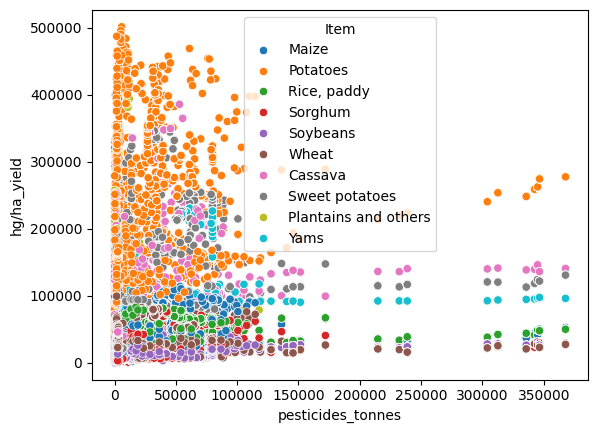

In [ ]:
# Linearity find between Y and X[pesticides_tonnes]
sns.scatterplot(x=X['pesticides_tonnes'], y=Y, hue=X['Item'])

<Axes: xlabel='avg_temp', ylabel='hg/ha_yield'>

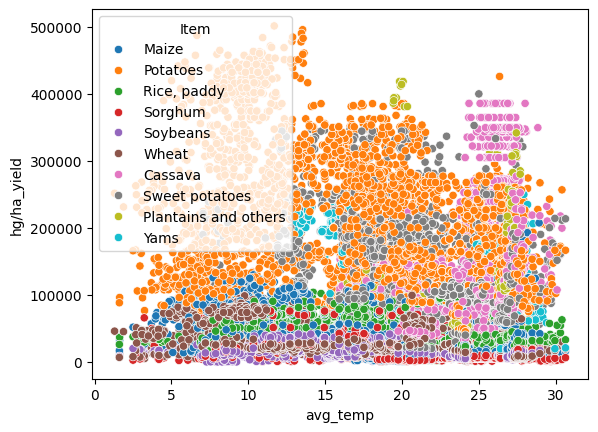

In [ ]:
# Linearity find between Y and X[avg_temp]
sns.scatterplot(x=X['avg_temp'], y=Y, hue=X['Item'])

In [ ]:
# 3D Plot
px.scatter_3d(x= X['average_rain_fall_mm_per_year'], y=X['avg_temp'], z = Y)

## **Outliers**

<Axes: xlabel='Item', ylabel='hg/ha_yield'>

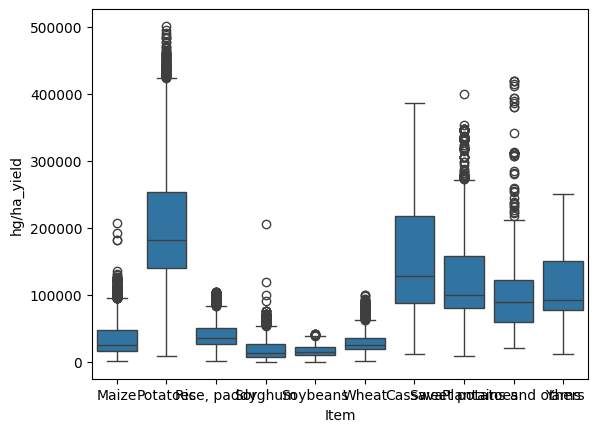

In [ ]:
# Outliers in y
sns.boxplot(x=X['Item'], y=Y)

<Axes: xlabel='average_rain_fall_mm_per_year'>

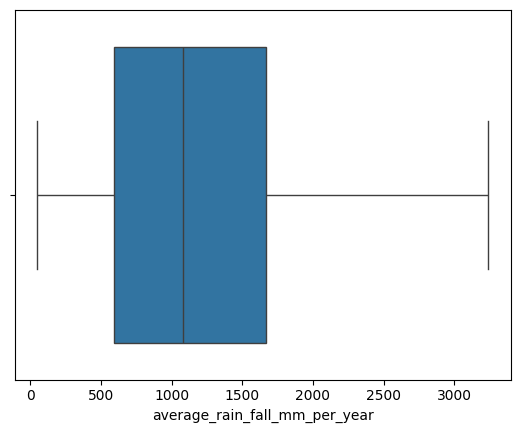

In [ ]:
# Outliers in
sns.boxplot(x=X['average_rain_fall_mm_per_year'])


<Axes: xlabel='pesticides_tonnes'>

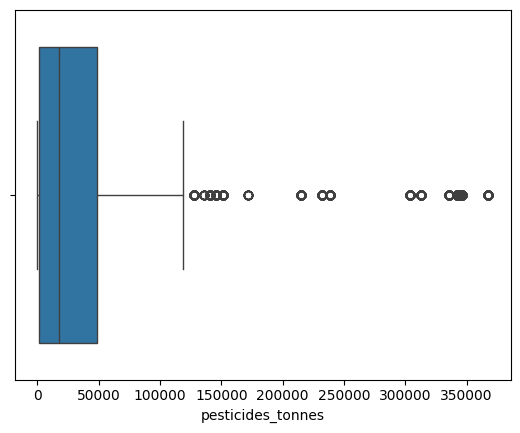

In [ ]:
sns.boxplot(x=X['pesticides_tonnes'])

<Axes: xlabel='avg_temp'>

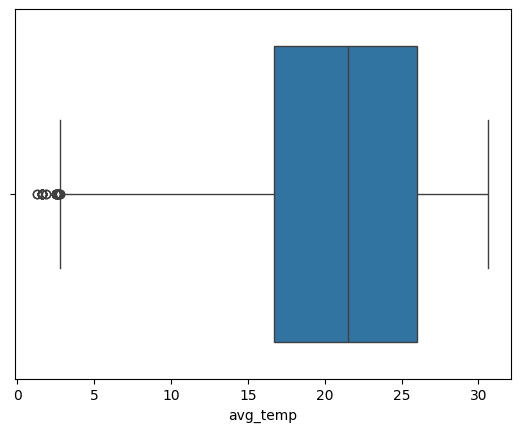

In [ ]:
sns.boxplot(x=X['avg_temp'])

In [ ]:
# Outliers capping in X['pesticides_tonnes']

# IQR range
percentile75 = X['pesticides_tonnes'].quantile(0.75)
percentile25 = X['pesticides_tonnes'].quantile(0.25)
iqr = percentile75 - percentile25


# limit define
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

lower_limit, upper_limit

# Outliers at right
X_capped = X.copy()
X_capped['pesticides_tonnes'] = np.where(X['pesticides_tonnes'] > upper_limit, upper_limit, X['pesticides_tonnes'])
X_capped.shape

(28242, 4)

In [ ]:
# Outliers capping in X['avg_temp']

# IQR range
percentile75 = X['avg_temp'].quantile(0.75)
percentile25 = X['avg_temp'].quantile(0.25)
iqr = percentile75 - percentile25


# limit define
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

# Outliers at left
X_capped['avg_temp'] = np.where(X['avg_temp'] < lower_limit , lower_limit, X['avg_temp'])
X_capped.shape

(28242, 4)

## **Features Corellation Identifying**

<Axes: >

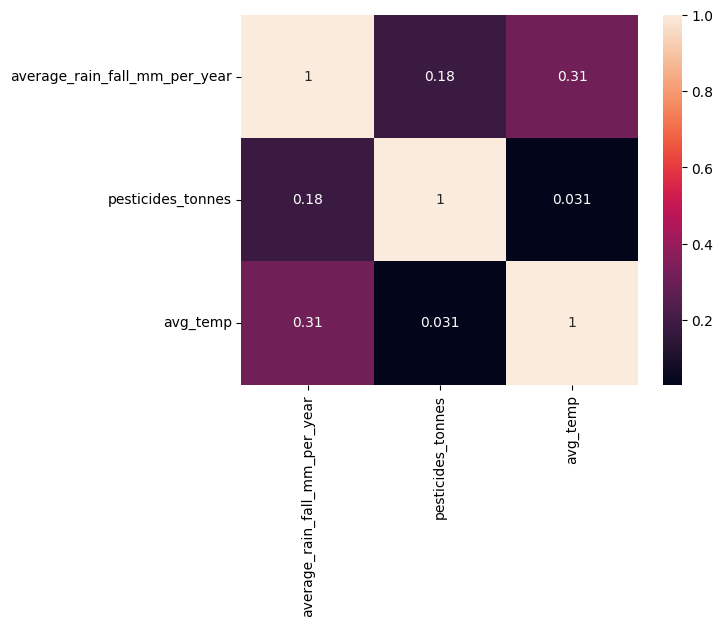

In [ ]:
corr_mat = X.drop(columns=['Item']).corr()
sns.heatmap(corr_mat, annot=True)

- No feature is highly corellated to other

## **Corellation With Y**

<Axes: >

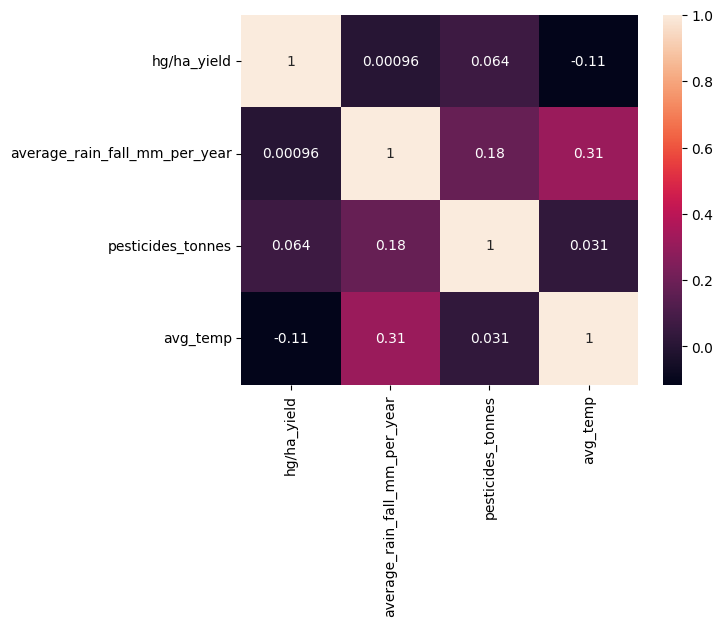

In [ ]:
sns.heatmap(data.drop(columns=['Item']).corr(), annot=True)

## **Feature Transformation**

In [ ]:
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [ ]:
X_capped.head()

,Item,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Maize,1485.0,121.0,16.37
1,Potatoes,1485.0,121.0,16.37
2,"Rice, paddy",1485.0,121.0,16.37
3,Sorghum,1485.0,121.0,16.37
4,Soybeans,1485.0,121.0,16.37


In [ ]:
encoder = ColumnTransformer([
        ('ordinal_encoder', OrdinalEncoder(categories=[sorted_crop_names]), ['Item']) # Changed 'Item' to ['Item']
    ], remainder='passthrough')

X_transformed = encoder.fit_transform(X_capped)

X_transformed

array([[5.00000e+00, 1.48500e+03, 1.21000e+02, 1.63700e+01],
       [0.00000e+00, 1.48500e+03, 1.21000e+02, 1.63700e+01],
       [7.00000e+00, 1.48500e+03, 1.21000e+02, 1.63700e+01],
       ...,
       [9.00000e+00, 6.57000e+02, 2.55007e+03, 1.97600e+01],
       [2.00000e+00, 6.57000e+02, 2.55007e+03, 1.97600e+01],
       [8.00000e+00, 6.57000e+02, 2.55007e+03, 1.97600e+01]])

In [ ]:
sc = StandardScaler()
X_transfored_scaled = sc.fit_transform(X_transformed)
X_transfored_scaled

array([[ 0.03467055,  0.47329419, -0.89886992, -0.66140646],
       [-1.63455138,  0.47329419, -0.89886992, -0.66140646],
       [ 0.70235932,  0.47329419, -0.89886992, -0.66140646],
       ...,
       [ 1.37004808, -0.69323228, -0.82639631, -0.12414876],
       [-0.96686261, -0.69323228, -0.82639631, -0.12414876],
       [ 1.0362037 , -0.69323228, -0.82639631, -0.12414876]])

## **Train Test Split**

In [ ]:
X_capped.head()

,Item,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Maize,1485.0,121.0,16.37
1,Potatoes,1485.0,121.0,16.37
2,"Rice, paddy",1485.0,121.0,16.37
3,Sorghum,1485.0,121.0,16.37
4,Soybeans,1485.0,121.0,16.37


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X_transfored_scaled, Y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((22593, 4), (5649, 4), (22593,), (5649,))

In [ ]:
X_train

array([[ 0.36851493,  0.64094715, -0.87772846,  0.7633566 ],
       [ 1.37004808, -0.09306286,  1.20963654,  0.8505223 ],
       [-0.63301822,  0.20138645, -0.88802186,  0.83467399],
       ...,
       [-1.63455138, -0.86652063, -0.36943102, -0.28738635],
       [-0.96686261, -0.44668381,  1.32379485, -1.30960233],
       [-0.96686261, -0.41568914, -0.44267827, -0.70578173]])

## ***Models Selection***

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score

In [ ]:
def evaluate_model(true, predicted):
  mae = mean_absolute_error(true, predicted)
  mse = mean_squared_error(true, predicted)
  r2 = r2_score(true, predicted)
  return {'mae': mae, 'mse': mse, 'r2': r2}

def cross_validation(model, X, Y):
  scores = cross_val_score(model, X, Y, cv=5)
  return scores.mean()

## **1. LR**

In [ ]:
lr = LinearRegression()
lr.fit(X_train, Y_train)

Y_pred = lr.predict(X_test)
evaluate_model(Y_test, Y_pred)

{'mae': 40287.964909162205, 'mse': 3181980906.725, 'r2': 0.5613282597413317}

In [ ]:
cross_validation(lr, X_train, Y_train)

np.float64(0.5504320194039769)

## **2. RFR**

In [ ]:
rfr = RandomForestRegressor()
rfr.fit(X_train, Y_train)

Y_pred = rfr.predict(X_test)
evaluate_model(Y_test, Y_pred)

{'mae': 6406.5285649866655,
 'mse': 226521358.63667408,
 'r2': 0.9687714912465704}

In [ ]:
cross_validation(rfr, X_train, Y_train)

np.float64(0.9669272322131777)

## **3. DTR**

In [ ]:
dtr = DecisionTreeRegressor()
dtr.fit(X_train, Y_train)

Y_pred = dtr.predict(X_test)
evaluate_model(Y_test, Y_pred)

{'mae': 6983.788841682894, 'mse': 363885008.2336254, 'r2': 0.9498343722055276}

In [ ]:
cross_validation(dtr, X_train, Y_train)

np.float64(0.9425460254643717)

## **4. SVR**

In [ ]:
svr = SVR()
svr.fit(X_train, Y_train)

Y_pred = svr.predict(X_test)
evaluate_model(Y_test, Y_pred)

{'mae': 56358.2866894715, 'mse': 8535506661.147953, 'r2': -0.1767152823330329}

In [ ]:
cross_validation(svr, X_train, Y_train)

np.float64(-0.18342487959451043)

## **5. XGB**

In [ ]:
xgb = XGBRegressor()
xgb.fit(X_train, Y_train)

Y_pred = xgb.predict(X_test)
evaluate_model(Y_test, Y_pred)

{'mae': 8769.873046875, 'mse': 259275664.0, 'r2': 0.9642559289932251}

In [ ]:
cross_validation(xgb, X_train, Y_train)


np.float64(0.9621197342872619)

---
### ***Selecting XGB as the final model***
- It gives
  - High r2
  - High cross_val_score
  - cross_val_score ~ r2 -> no overfitting
  - Low latency
---

## **Pipeline**

In [ ]:
xgb.predict(X_test)

array([ 71843.62 ,  16606.984,  44903.87 , ..., 251817.7  ,  28865.543,
        22606.541], dtype=float32)

In [ ]:
Y_test

,hg/ha_yield
25564,69220
18113,20000
25607,51206
6815,166986
18144,56319
...,...
25027,30142
5508,140000
11393,252775
16688,24615


In [ ]:
evaluate_model(Y_test, xgb.predict(X_test))

{'mae': 7389.81884765625, 'mse': 162409664.0, 'r2': 0.9776099920272827}

In [ ]:
from sklearn.pipeline import Pipeline
pipeline = Pipeline([
    ('encoder', encoder),
    ('scaler', sc),
    ('model', xgb)
])

In [ ]:
pipeline.fit(X_capped, Y)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning:


The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).




Pipeline(steps=[('encoder',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinal_encoder',
                                                  OrdinalEncoder(categories=[array(['Potatoes', 'Plantains and others', 'Sweet potatoes', 'Cassava',
       'Yams', 'Maize', 'Sorghum', 'Rice, paddy', 'Wheat', 'Soybeans'],
      dtype=object)]),
                                                  ['Item'])])),
                ('scaler', StandardScaler()),
                ('model',
                 XGBRegressor(base_score=None, boo...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [ ]:
xgb.predict(X_transfored_scaled)

array([22473.38 , 70544.98 , 31835.898, ..., 16945.74 , 32661.951,
       35188.305], dtype=float32)

In [ ]:
Y_pipeline_pred = pipeline.predict(X_capped)
Y_pipeline_pred

array([22473.38 , 70544.98 , 31835.898, ..., 16945.74 , 32661.951,
       35188.305], dtype=float32)

In [ ]:
Y.values

array([36613, 66667, 23333, ..., 13142, 22222, 22888])

In [ ]:
evaluate_model(Y, Y_pipeline_pred)

{'mae': 7300.9365234375, 'mse': 156150448.0, 'r2': 0.9783646464347839}

In [ ]:
# Save the pipeline
